In [46]:
import os
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.signal import hilbert
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from scipy.signal import find_peaks
from sklearn.feature_selection import SelectFromModel

In [47]:
# ==========================
# Dataset Paths
# ==========================

TRAIN_PATH = r"C:\Users\Sohana Pilli\Desktop\TASL 2\Dataset 250 Msps"

TEST_PATH = r"C:\Users\Sohana Pilli\Desktop\TASL 2\Dataset 250 Msps_test"

In [48]:
def dataset_summary(dataset_path):

    total_brands = 0
    total_models = 0
    total_users = 0
    total_files = 0

    print("="*60)
    print(dataset_path)
    print("="*60)

    for brand in sorted(os.listdir(dataset_path)):

        brand_path = os.path.join(dataset_path, brand)

        if not os.path.isdir(brand_path):
            continue

        total_brands += 1

        print(f"\nBrand : {brand}")

        for model in sorted(os.listdir(brand_path)):

            model_path = os.path.join(brand_path, model)

            if not os.path.isdir(model_path):
                continue

            total_models += 1

            users = sorted(os.listdir(model_path))

            print(f"   {model} -> {len(users)} users")

            for user in users:

                user_path = os.path.join(model_path, user)

                if not os.path.isdir(user_path):
                    continue

                total_users += 1

                txt_files = glob.glob(os.path.join(user_path, "*.txt"))

                total_files += len(txt_files)

    print("\n")
    print("="*60)
    print("SUMMARY")
    print("="*60)
    print("Brands :", total_brands)
    print("Models :", total_models)
    print("Users  :", total_users)
    print("Files  :", total_files)

In [49]:
print("TRAIN DATASET\n")
dataset_summary(TRAIN_PATH)

print("\n\nTEST DATASET\n")
dataset_summary(TEST_PATH)

TRAIN DATASET

C:\Users\Sohana Pilli\Desktop\TASL 2\Dataset 250 Msps

Brand : Iphone
   4s -> 2 users
   5 -> 2 users
   5s -> 2 users
   6 -> 2 users
   6S -> 3 users
   7 -> 2 users
   7plus -> 2 users

Brand : LG
   G4 -> 2 users
   V20 -> 2 users

Brand : Samsung
   J7 -> 2 users
   Note2 -> 2 users
   S5 -> 2 users
   S7 edge -> 2 users
   note3 -> 2 users

Brand : Sony
   XperiaM5 -> 2 users

Brand : Xiaomi
   Mi6 -> 2 users


SUMMARY
Brands : 5
Models : 16
Users  : 33
Files  : 3960


TEST DATASET

C:\Users\Sohana Pilli\Desktop\TASL 2\Dataset 250 Msps_test

Brand : Iphone
   4s -> 2 users
   5 -> 2 users
   5s -> 2 users
   6 -> 2 users
   6S -> 3 users
   7 -> 2 users
   7plus -> 2 users

Brand : LG
   G4 -> 2 users
   V20 -> 2 users

Brand : Samsung
   J7 -> 2 users
   Note2 -> 2 users
   S5 -> 2 users
   S7 edge -> 2 users
   note3 -> 2 users

Brand : Sony
   XperiaM5 -> 2 users

Brand : Xiaomi
   Mi6 -> 2 users


SUMMARY
Brands : 5
Models : 16
Users  : 33
Files  : 990


In [50]:
print("TEST DATASET\n")
dataset_summary(TEST_PATH)

TEST DATASET

C:\Users\Sohana Pilli\Desktop\TASL 2\Dataset 250 Msps_test

Brand : Iphone
   4s -> 2 users
   5 -> 2 users
   5s -> 2 users
   6 -> 2 users
   6S -> 3 users
   7 -> 2 users
   7plus -> 2 users

Brand : LG
   G4 -> 2 users
   V20 -> 2 users

Brand : Samsung
   J7 -> 2 users
   Note2 -> 2 users
   S5 -> 2 users
   S7 edge -> 2 users
   note3 -> 2 users

Brand : Sony
   XperiaM5 -> 2 users

Brand : Xiaomi
   Mi6 -> 2 users


SUMMARY
Brands : 5
Models : 16
Users  : 33
Files  : 990


In [51]:
import os
import glob

train_user = os.path.join(TRAIN_PATH, "Iphone", "7plus", sorted(os.listdir(os.path.join(TRAIN_PATH, "Iphone", "7plus")))[0])
test_user  = os.path.join(TEST_PATH, "Iphone", "7plus", sorted(os.listdir(os.path.join(TEST_PATH, "Iphone", "7plus")))[0])

print("Train user folder:", train_user)
print("Train txt files:", len(glob.glob(os.path.join(train_user, "*.txt"))))

print()

print("Test user folder:", test_user)
print("Test txt files:", len(glob.glob(os.path.join(test_user, "*.txt"))))

Train user folder: C:\Users\Sohana Pilli\Desktop\TASL 2\Dataset 250 Msps\Iphone\7plus\355373083202269_akin_yavuz
Train txt files: 120

Test user folder: C:\Users\Sohana Pilli\Desktop\TASL 2\Dataset 250 Msps_test\Iphone\7plus\355373083202269_akin_yavuz_test
Test txt files: 30


In [52]:
def load_signal(file_path):
    """
    Reads a waveform text file and returns a NumPy array.
    """

    signal = np.loadtxt(file_path)

    signal = signal.astype(np.float32)

    return signal

In [53]:
def normalize_signal(signal):
    """
    Zero-mean and unit-variance normalization.
    """

    signal = signal - np.mean(signal)

    std = np.std(signal)

    if std != 0:
        signal = signal / std

    return signal

In [54]:
def generate_iq(signal):
    """
    Generate analytic IQ signal using Hilbert transform.
    """

    analytic_signal = hilbert(signal)

    I = np.real(analytic_signal)

    Q = np.imag(analytic_signal)

    return I, Q

In [55]:
def process_dataset(dataset_path):

    data = []

    for brand in sorted(os.listdir(dataset_path)):

        brand_path = os.path.join(dataset_path, brand)

        if not os.path.isdir(brand_path):
            continue

        for model in sorted(os.listdir(brand_path)):

            model_path = os.path.join(brand_path, model)

            if not os.path.isdir(model_path):
                continue

            for user in sorted(os.listdir(model_path)):

                user_path = os.path.join(model_path, user)

                if not os.path.isdir(user_path):
                    continue

                txt_files = sorted(glob.glob(os.path.join(user_path, "*.txt")))

                for file in txt_files:

                    signal = load_signal(file)

                    signal = normalize_signal(signal)

                    I, Q = generate_iq(signal)

                    data.append({
                        "brand": brand,
                        "model": model,
                        "user": user,
                        "file": os.path.basename(file),
                        "signal": signal,
                        "I": I,
                        "Q": Q
                    })

    return pd.DataFrame(data)

In [56]:
train_df = process_dataset(TRAIN_PATH)

test_df = process_dataset(TEST_PATH)

print("Train shape :", train_df.shape)
print("Test shape  :", test_df.shape)

Train shape : (3960, 7)
Test shape  : (990, 7)


In [57]:
def extract_features(I, Q):

    features = {}

    amplitude = np.sqrt(I**2 + Q**2)
    phase = np.unwrap(np.arctan2(Q, I))
    energy = I**2 + Q**2

    fft = np.abs(np.fft.rfft(amplitude))
    fft_freq = np.fft.rfftfreq(len(amplitude))

    psd = fft**2
    psd = psd / (np.sum(psd) + 1e-12)

    # ===================================================
    # Amplitude Features
    # ===================================================

    features["amp_mean"] = np.mean(amplitude)
    features["amp_std"] = np.std(amplitude)
    features["amp_var"] = np.var(amplitude)
    features["amp_min"] = np.min(amplitude)
    features["amp_max"] = np.max(amplitude)
    features["amp_range"] = np.ptp(amplitude)
    features["amp_median"] = np.median(amplitude)
    features["amp_rms"] = np.sqrt(np.mean(amplitude**2))
    features["amp_skew"] = skew(amplitude)
    features["amp_kurtosis"] = kurtosis(amplitude)

    features["amp_q25"] = np.percentile(amplitude,25)
    features["amp_q75"] = np.percentile(amplitude,75)
    features["amp_iqr"] = features["amp_q75"]-features["amp_q25"]

    # ===================================================
    # Phase Features
    # ===================================================

    features["phase_mean"] = np.mean(phase)
    features["phase_std"] = np.std(phase)
    features["phase_var"] = np.var(phase)
    features["phase_range"] = np.ptp(phase)
    features["phase_skew"] = skew(phase)
    features["phase_kurtosis"] = kurtosis(phase)

    # ===================================================
    # I Features
    # ===================================================

    features["I_mean"] = np.mean(I)
    features["I_std"] = np.std(I)
    features["I_var"] = np.var(I)
    features["I_rms"] = np.sqrt(np.mean(I**2))
    features["I_skew"] = skew(I)
    features["I_kurtosis"] = kurtosis(I)

    # ===================================================
    # Q Features
    # ===================================================

    features["Q_mean"] = np.mean(Q)
    features["Q_std"] = np.std(Q)
    features["Q_var"] = np.var(Q)
    features["Q_rms"] = np.sqrt(np.mean(Q**2))
    features["Q_skew"] = skew(Q)
    features["Q_kurtosis"] = kurtosis(Q)

    # ===================================================
    # Energy
    # ===================================================

    features["energy_sum"] = np.sum(energy)
    features["energy_mean"] = np.mean(energy)
    features["energy_std"] = np.std(energy)
    features["energy_var"] = np.var(energy)
    features["energy_max"] = np.max(energy)

    # ===================================================
    # Crest Factor & PAPR
    # ===================================================

    rms = np.sqrt(np.mean(amplitude**2))

    features["crest_factor"] = np.max(amplitude)/(rms+1e-12)

    power = amplitude**2

    features["papr"] = np.max(power)/(np.mean(power)+1e-12)

    # ===================================================
    # Zero Crossing Rate
    # ===================================================

    features["zcr"] = np.mean(np.diff(np.sign(amplitude))!=0)

    # ===================================================
    # Spectral Features
    # ===================================================

    features["fft_mean"] = np.mean(fft)
    features["fft_std"] = np.std(fft)
    features["fft_max"] = np.max(fft)
    features["fft_energy"] = np.sum(fft**2)

    features["spectral_entropy"] = -np.sum(psd*np.log2(psd+1e-12))

    centroid = np.sum(fft_freq*fft)/(np.sum(fft)+1e-12)

    features["spectral_centroid"] = centroid

    bandwidth = np.sqrt(
        np.sum(((fft_freq-centroid)**2)*fft)/(np.sum(fft)+1e-12)
    )

    features["spectral_bandwidth"] = bandwidth

    cumulative = np.cumsum(psd)

    features["spectral_rolloff"] = fft_freq[np.where(cumulative>=0.85)[0][0]]

    geometric = np.exp(np.mean(np.log(fft+1e-12)))
    arithmetic = np.mean(fft)

    features["spectral_flatness"] = geometric/(arithmetic+1e-12)

    # ===================================================
    # Hjorth Parameters
    # ===================================================

    d1 = np.diff(amplitude)
    d2 = np.diff(d1)

    var0 = np.var(amplitude)
    var1 = np.var(d1)
    var2 = np.var(d2)

    features["hjorth_activity"] = var0

    features["hjorth_mobility"] = np.sqrt(var1/(var0+1e-12))

    features["hjorth_complexity"] = (
        np.sqrt(var2/(var1+1e-12))
        /(features["hjorth_mobility"]+1e-12)
    )

    # ===================================================
    # Peak Features
    # ===================================================

    peaks,_ = find_peaks(amplitude)

    features["num_peaks"] = len(peaks)

    if len(peaks)>0:

        features["peak_mean"] = np.mean(amplitude[peaks])

        features["peak_std"] = np.std(amplitude[peaks])

    else:

        features["peak_mean"] = 0

        features["peak_std"] = 0

    # ===================================================
    # Autocorrelation
    # ===================================================

    ac = np.correlate(amplitude,amplitude,mode="full")

    ac = ac[len(ac)//2:]

    features["autocorr_lag1"] = ac[1]

    features["autocorr_mean"] = np.mean(ac)

    features["autocorr_std"] = np.std(ac)

    return features

In [58]:
def build_feature_dataframe(df):

    rows = []

    for _, row in df.iterrows():

        features = extract_features(row["I"], row["Q"])

        features["brand"] = row["brand"]
        features["model"] = row["model"]
        features["user"] = row["user"]

        rows.append(features)

    return pd.DataFrame(rows)

In [59]:
train_feature_df = build_feature_dataframe(train_df)
test_feature_df = build_feature_dataframe(test_df)

print(train_feature_df.shape)
print(test_feature_df.shape)

train_feature_df.head()

(3960, 60)
(990, 60)


,amp_mean,amp_std,amp_var,amp_min,amp_max,amp_range,amp_median,amp_rms,amp_skew,amp_kurtosis,...,hjorth_complexity,num_peaks,peak_mean,peak_std,autocorr_lag1,autocorr_mean,autocorr_std,brand,model,user
0,1.021678,0.977841,0.956173,0.020680,2.440731,2.420052,0.275787,1.414213,0.233063,-1.872272,...,15.665657,505,0.921576,0.964062,4291.659668,1123.635864,1340.962891,Iphone,4s,013004004984503_oguz_guler
1,1.007676,0.992265,0.984590,0.008428,2.485348,2.476920,0.225290,1.414213,0.267395,-1.861317,...,16.588427,523,0.890361,0.975705,4295.105957,1093.073120,1340.604614,Iphone,4s,013004004984503_oguz_guler
2,1.026174,0.973122,0.946966,0.013217,2.517478,2.504261,0.278300,1.414213,0.233915,-1.865316,...,13.696608,579,1.081809,0.988444,4287.090820,1133.537476,1336.320557,Iphone,4s,013004004984503_oguz_guler
3,1.020540,0.979029,0.958497,0.017332,2.481246,2.463914,0.265642,1.414213,0.249956,-1.860951,...,14.431155,507,0.971994,0.981513,4290.621582,1121.135742,1335.499023,Iphone,4s,013004004984503_oguz_guler
4,1.020339,0.979238,0.958908,0.015392,2.469015,2.453623,0.253146,1.414213,0.252574,-1.861210,...,15.290190,529,0.933923,0.976675,4293.555176,1120.693970,1335.306641,Iphone,4s,013004004984503_oguz_guler


In [60]:
# Remove "_test" suffix from test user names

test_feature_df["user"] = test_feature_df["user"].str.replace(
    "_test",
    "",
    regex=False
)

In [61]:
# Target = User (Device ID)

X_train = train_feature_df.drop(columns=["brand", "model", "user"])

y_train = train_feature_df["user"]

X_test = test_feature_df.drop(columns=["brand", "model", "user"])

y_test = test_feature_df["user"]

print(X_train.shape)
print(X_test.shape)

(3960, 57)
(990, 57)


In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

y_test = label_encoder.transform(y_test)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [64]:
from sklearn.metrics import accuracy_score, classification_report

# Training predictions
y_train_pred = rf.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

print(classification_report(y_train, y_train_pred))

Training Accuracy: 0.9977272727272727
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00       120
           2       0.99      1.00      1.00       120
           3       1.00      0.99      1.00       120
           4       1.00      0.99      1.00       120
           5       1.00      1.00      1.00       120
           6       1.00      1.00      1.00       120
           7       1.00      1.00      1.00       120
           8       1.00      1.00      1.00       120
           9       1.00      1.00      1.00       120
          10       1.00      0.99      1.00       120
          11       0.98      1.00      0.99       120
          12       0.99      1.00      1.00       120
          13       1.00      0.98      0.99       120
          14       0.98      1.00      0.99       120
          15       1.00      1.00      1.00       120
          16       1.00      0.99      1.00

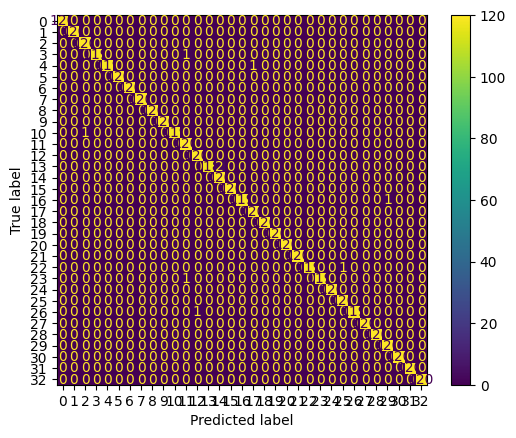

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

In [66]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

param_grid = {
    "n_estimators":[300,500,700,1000],
    "max_depth":[3,4,5,6,7,8],
    "learning_rate":[0.01,0.03,0.05,0.1],
    "subsample":[0.7,0.8,0.9,1.0],
    "colsample_bytree":[0.7,0.8,0.9,1.0],
    "min_child_weight":[1,3,5],
    "gamma":[0,0.1,0.3,0.5]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train,y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}
0.9068181818181819


In [67]:
best_xgb = search.best_estimator_

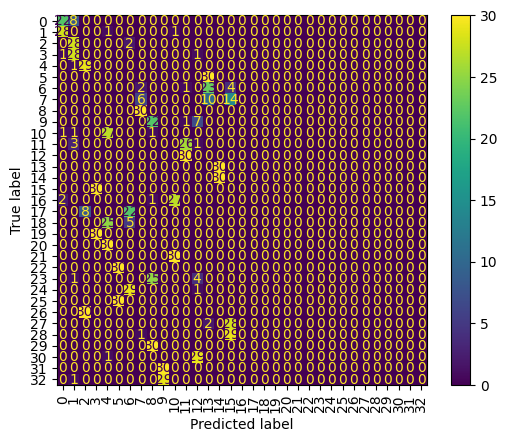

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    xticks_rotation=90
)

In [69]:
print(train_feature_df.columns)

Index(['amp_mean', 'amp_std', 'amp_var', 'amp_min', 'amp_max', 'amp_range',
       'amp_median', 'amp_rms', 'amp_skew', 'amp_kurtosis', 'amp_q25',
       'amp_q75', 'amp_iqr', 'phase_mean', 'phase_std', 'phase_var',
       'phase_range', 'phase_skew', 'phase_kurtosis', 'I_mean', 'I_std',
       'I_var', 'I_rms', 'I_skew', 'I_kurtosis', 'Q_mean', 'Q_std', 'Q_var',
       'Q_rms', 'Q_skew', 'Q_kurtosis', 'energy_sum', 'energy_mean',
       'energy_std', 'energy_var', 'energy_max', 'crest_factor', 'papr', 'zcr',
       'fft_mean', 'fft_std', 'fft_max', 'fft_energy', 'spectral_entropy',
       'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff',
       'spectral_flatness', 'hjorth_activity', 'hjorth_mobility',
       'hjorth_complexity', 'num_peaks', 'peak_mean', 'peak_std',
       'autocorr_lag1', 'autocorr_mean', 'autocorr_std', 'brand', 'model',
       'user'],
      dtype='str')


In [70]:
feature_names = train_feature_df.drop(
    columns=["brand", "model", "user"]
).columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": et.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
56        autocorr_std    0.069519
31          energy_sum    0.043604
54       autocorr_lag1    0.043570
9         amp_kurtosis    0.041704
42          fft_energy    0.036503
40             fft_std    0.032911
34          energy_var    0.031434
33          energy_std    0.031121
8             amp_skew    0.030875
46    spectral_rolloff    0.029924
41             fft_max    0.029820
6           amp_median    0.029574
24          I_kurtosis    0.027436
11             amp_q75    0.027189
30          Q_kurtosis    0.026806
43    spectral_entropy    0.025686
55       autocorr_mean    0.023791
0             amp_mean    0.020601
1              amp_std    0.020214
2              amp_var    0.019943
12             amp_iqr    0.019779
10             amp_q25    0.019689
48     hjorth_activity    0.019342
49     hjorth_mobility    0.019111
50   hjorth_complexity    0.017436
39            fft_mean    0.017125
44   spectral_centroid    0.016108
3              amp_m

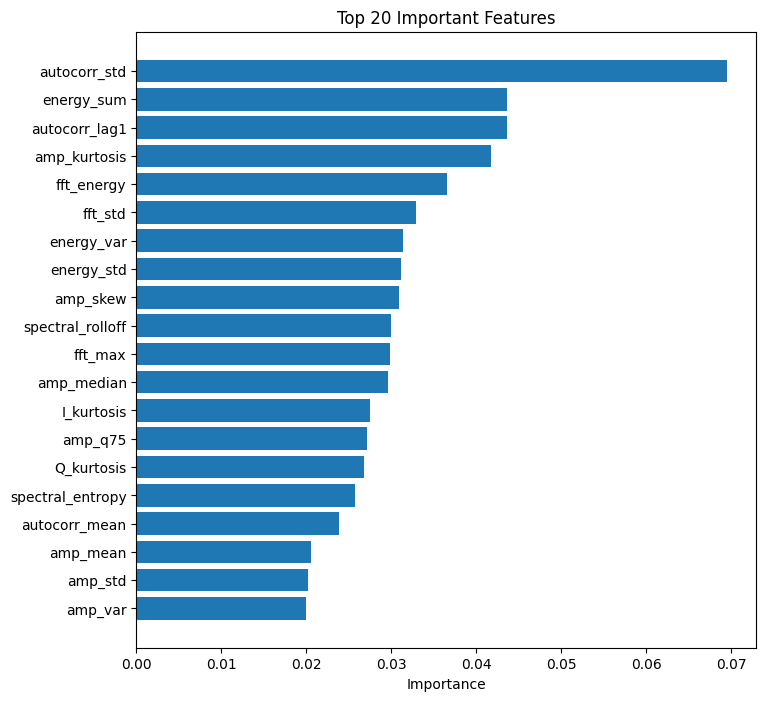

In [71]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(8,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Important Features")
plt.show()

In [72]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report

selector = SelectFromModel(
    et,
    threshold="median",
    prefit=True
)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

print("Original Features :", X_train.shape[1])
print("Selected Features :", X_train_selected.shape[1])

et_selected = ExtraTreesClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

et_selected.fit(X_train_selected, y_train)

pred = et_selected.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Original Features : 57
Selected Features : 29
Accuracy: 0.8525252525252526
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        30
           1       0.88      0.93      0.90        30
           2       0.90      0.87      0.88        30
           3       0.79      0.87      0.83        30
           4       0.79      0.63      0.70        30
           5       0.82      0.93      0.88        30
           6       0.46      0.60      0.52        30
           7       0.62      0.27      0.37        30
           8       1.00      1.00      1.00        30
           9       0.43      0.63      0.51        30
          10       0.96      0.87      0.91        30
          11       0.93      0.83      0.88        30
          12       1.00      1.00      1.00        30
          13       0.88      0.93      0.90        30
          14       0.93      0.83      0.88        30
          15       1.00      1.00      1.00        30
      

In [73]:
print(search.best_params_)
print(search.best_score_)

{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}
0.9068181818181819


In [74]:
best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X_test)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.8858585858585859


In [75]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'os', 'glob', 'np', 'pd', 'plt', 'hilbert', 'skew', 'kurtosis', 'LabelEncoder', 'StandardScaler', 'accuracy_score', 'classification_report', 'confusion_matrix', 'ConfusionMatrixDisplay', 'find_peaks', 'SelectFromModel', '_i2', 'TRAIN_PATH', 'TEST_PATH', '_i3', 'dataset_summary', '_i4', '_i5', '_i6', 'train_user', 'test_user', '_i7', 'load_signal', '_i8', 'normalize_signal', '_i9', 'generate_iq', '_i10', 'process_dataset', '_i11', 'train_df', 'test_df', '_i12', 'extract_features', '_i13', 'build_feature_dataframe', '_i14', 'train_feature_df', 'test_feature_df', '_14', '_i15', '_i16', 'X_train', 'y_train', 'X_test', 'y_test', '_i17', 'label_encoder', '_i18', 'scaler', '_i19', 'RandomForestClassifier', 'rf', '_19', '_i20', 'y_train_pred', '_i21',

In [76]:
rf.fit(X_train, y_train)
et.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


Brand Accuracy: 0.9737373737373738
              precision    recall  f1-score   support

      Iphone       0.99      0.99      0.99       450
          LG       0.99      0.88      0.93       120
     Samsung       0.94      0.98      0.96       300
        Sony       1.00      1.00      1.00        60
      Xiaomi       1.00      1.00      1.00        60

    accuracy                           0.97       990
   macro avg       0.98      0.97      0.98       990
weighted avg       0.97      0.97      0.97       990



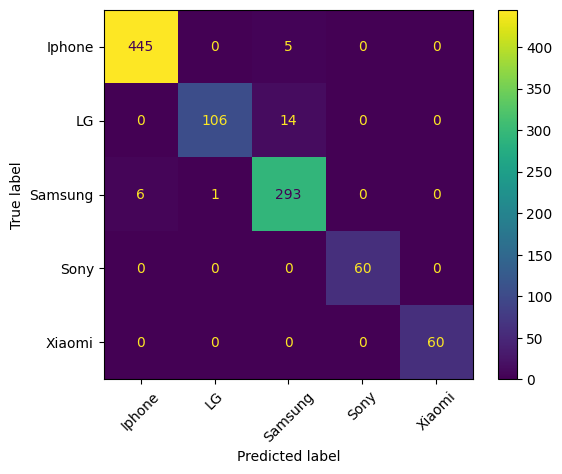

In [77]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# -----------------------------
# Features
# -----------------------------
X_train = train_feature_df.drop(columns=["brand", "model", "user"])
X_test = test_feature_df.drop(columns=["brand", "model", "user"])

# Scale
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Labels
# -----------------------------
brand_encoder = LabelEncoder()

y_train = brand_encoder.fit_transform(train_feature_df["brand"])
y_test = brand_encoder.transform(test_feature_df["brand"])

# -----------------------------
# Tuned XGBoost
# -----------------------------
brand_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,

    subsample=0.8,
    n_estimators=500,
    min_child_weight=1,
    max_depth=8,
    learning_rate=0.03,
    gamma=0.1,
    colsample_bytree=0.7
)

brand_model.fit(X_train, y_train)

# Prediction
pred = brand_model.predict(X_test)

# Accuracy
print("Brand Accuracy:", accuracy_score(y_test, pred))

# Report
print(classification_report(
    y_test,
    pred,
    target_names=brand_encoder.classes_
))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=brand_encoder.classes_,
    xticks_rotation=45
)

plt.show()

Model Accuracy: 0.8898989898989899
              precision    recall  f1-score   support

          4s       0.93      0.83      0.88        60
           5       0.79      0.93      0.85        60
          5s       0.88      0.98      0.93        60
           6       1.00      1.00      1.00        60
          6S       0.98      0.91      0.94        90
           7       1.00      1.00      1.00        60
       7plus       0.88      0.85      0.86        60
          G4       0.92      0.60      0.73        60
          J7       0.66      0.87      0.75        60
         Mi6       1.00      0.98      0.99        60
       Note2       0.98      0.95      0.97        60
          S5       0.97      0.93      0.95        60
     S7 edge       0.77      0.55      0.64        60
         V20       0.82      0.88      0.85        60
    XperiaM5       1.00      1.00      1.00        60
       note3       0.76      0.95      0.84        60

    accuracy                           0.89  

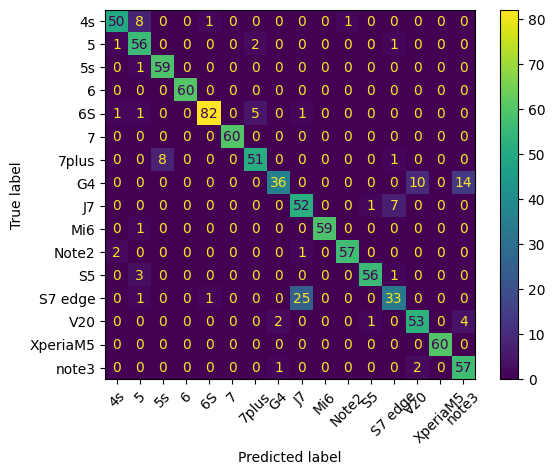

In [78]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# -----------------------------
# Features
# -----------------------------
X_train = train_feature_df.drop(columns=["brand", "model", "user"])
X_test = test_feature_df.drop(columns=["brand", "model", "user"])

# Scale
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Labels
# -----------------------------
model_encoder = LabelEncoder()

y_train = model_encoder.fit_transform(train_feature_df["model"])
y_test = model_encoder.transform(test_feature_df["model"])

# -----------------------------
# Tuned XGBoost
# -----------------------------
model_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,

    subsample=0.8,
    n_estimators=500,
    min_child_weight=1,
    max_depth=8,
    learning_rate=0.03,
    gamma=0.1,
    colsample_bytree=0.7
)

model_model.fit(X_train, y_train)

# Prediction
pred = model_model.predict(X_test)

# Accuracy
print("Model Accuracy:", accuracy_score(y_test, pred))

# Report
print(classification_report(
    y_test,
    pred,
    target_names=model_encoder.classes_
))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=model_encoder.classes_,
    xticks_rotation=45
)

plt.show()